In [3]:
import classical_3D as main
import quantum_3D as quant

import sys
sys.path.append("../funcs")

import geometry as geo
import kernals as ker
import metrics as met

import numpy as np
import matplotlib.pyplot as plt

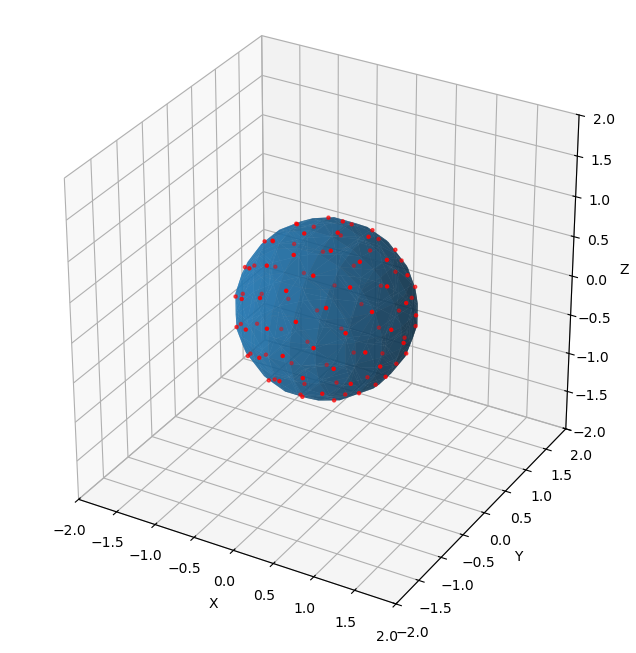

In [5]:

scan_points, scan_normals = geo.generate_sphere_points()

size = 2

Nx = 16
Ny = 16
Nz = 16

chi_grid, iso_value = main.surface_reconstruction_3d(scan_points, scan_normals, size, Nx, Ny, Nz, ker.gaussian, sigma=0.2)


import matplotlib.pyplot as plt
from skimage.measure import marching_cubes

x = np.linspace(-size, size, Nx)
y = np.linspace(-size, size, Ny)
z = np.linspace(-size, size, Nz)

verts, faces, normals, values = marching_cubes(
    chi_grid,
    level=iso_value,
    spacing=(x[1] - x[0],
             y[1] - y[0],
             z[1] - z[0])
)

verts[:, 0] += x[0]
verts[:, 1] += y[0]
verts[:, 2] += z[0]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(
    verts[:, 0],
    verts[:, 1],
    faces,
    verts[:, 2],
    alpha=0.7,
    edgecolor="none"
)

ax.scatter(
    scan_points[:, 0],
    scan_points[:, 1],
    scan_points[:, 2],
    color="red",
    s=5
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim(-size, size)
ax.set_ylim(-size, size)
ax.set_zlim(-size, size)

ax.set_box_aspect((1, 1, 1))

plt.show()



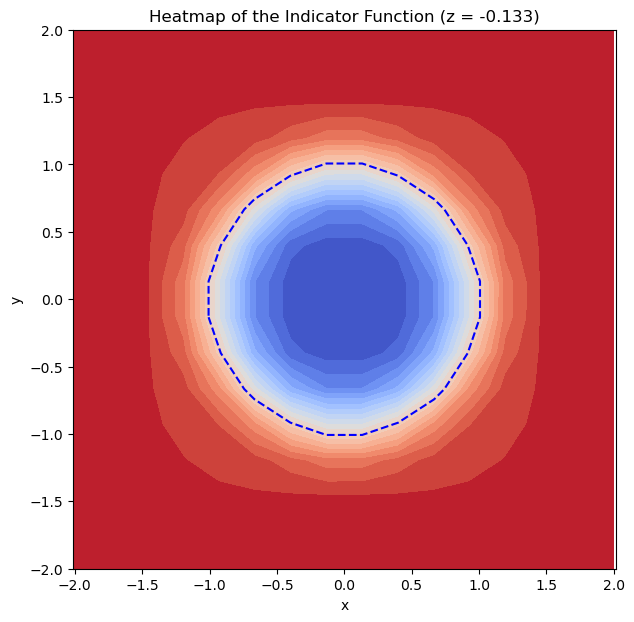

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-size, size, Nx)
y = np.linspace(-size, size, Ny)
z = np.linspace(-size, size, Nz)

z_index = np.argmin(np.abs(z))

chi_slice = chi_grid[:, :, z_index]

X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(7, 7))

plt.contour(
    X,
    Y,
    chi_slice,
    levels=[iso_value],
    colors="blue"
)

plt.contourf(
    X,
    Y,
    chi_slice,
    cmap="coolwarm",
    levels=20
)

plt.axis("equal")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Heatmap of the Indicator Function (z = {z[z_index]:.3f})")

plt.show()
